In [83]:
import pandas as pd
import numpy as np
import scipy as sns
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("QVI_data.csv")

In [3]:
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


<h2> building monthly kpis for every store </h2>

In [5]:
## converting the DATE to datetime instead of string
df["DATE"] = pd.to_datetime(df["DATE"])

In [7]:
df["DATE"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 264834 entries, 0 to 264833
Series name: DATE
Non-Null Count   Dtype         
--------------   -----         
264834 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.0 MB


In [8]:
## creating the yearmonth column
df["YEARMONTH"] = df["DATE"].dt.year * 100 + df["DATE"].dt.month

In [23]:
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,201811


In [24]:
# Aggregate monthly metrics
measure_over_time = (
    df.groupby(["STORE_NBR", "YEARMONTH"])
      .agg(
          totSales=("TOT_SALES", "sum"),
          nCustomers=("LYLTY_CARD_NBR", "nunique"),
          nTransactions=("TXN_ID", "nunique"),
          totalQty=("PROD_QTY", "sum")
      )
      .reset_index()
)
measure_over_time.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTransactions,totalQty
0,1,201807,206.9,49,52,62
1,1,201808,176.1,42,43,54
2,1,201809,278.8,59,62,75
3,1,201810,188.1,44,45,58
4,1,201811,192.6,46,47,57


In [25]:
# Derived metrics
measure_over_time["nTxnPerCust"] = (
    measure_over_time["nTransactions"] /
    measure_over_time["nCustomers"]
)

measure_over_time["nChipsPerTxn"] = (
    measure_over_time["totalQty"] /
    measure_over_time["nTransactions"]
)

measure_over_time["avgPricePerUnit"] = (
    measure_over_time["totSales"] /
    measure_over_time["totalQty"]
)

In [26]:
measure_over_time.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTransactions,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


In [31]:
## keep only stores with full history (12 months) for fair comparision later
store_counts = (df.groupby("STORE_NBR")["YEARMONTH"]
                .nunique())
store_counts

STORE_NBR
1      12
2      12
3      12
4      12
5      12
       ..
268    12
269    12
270    12
271    12
272    12
Name: YEARMONTH, Length: 272, dtype: int64

In [34]:
stores_with_full_obs = store_counts[store_counts==12].index

In [35]:
stores_with_full_obs

Int64Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
            ...
            263, 264, 265, 266, 267, 268, 269, 270, 271, 272],
           dtype='int64', name='STORE_NBR', length=260)

In [36]:
## the trial period starts at 2019-02
pretrial = measure_over_time[
    (measure_over_time["YEARMONTH"] < 201902) &
    (measure_over_time["STORE_NBR"].isin(stores_with_full_obs))
]

<h2>Find stores that behave similarly BEFORE the trial and choosing the best one as a control store for stores(77,86 and 88) based on total sales and number of customers and choose the best ones</h2>


---
### Correlation score
Does the candidate move **up and down in the same pattern** as the trial store? A high Pearson correlation means they share the same seasonal/trend drivers. When an external event depresses sales in October, we want both stores to dip together so the comparison stays fair.

### Magnitude score
Is the candidate **roughly the same size**? Two stores can be perfectly correlated in shape but one might be 5× larger. We compute the absolute monthly difference, normalise it to `[0, 1]` (1 = most similar), and average across months.

### finalControlScore
```
finalScore = 0.5 × corrScore + 0.5 × magScore
```
We apply this separately to `totSales` and `nCustomers`, then average again. The store with the **highest score** (excluding the trial store itself) becomes the control.

In [38]:
## using pearson correlation to see the trend behavor
import pandas as pd

def calculateCorrelation(inputTable, metricCol, storeComparison):

    calcCorrTable = pd.DataFrame(
        columns=["Store1", "Store2", "corr_measure"]
    )

    # all candidate stores
    storeNumbers = inputTable["STORE_NBR"].unique()

    # trial store data
    trial_store = inputTable[
        inputTable["STORE_NBR"] == storeComparison
    ][["YEARMONTH", metricCol]]

    for store in storeNumbers:

        if store != storeComparison:

            control_store = inputTable[
                inputTable["STORE_NBR"] == store
            ][["YEARMONTH", metricCol]]

            # merge on month
            merged = trial_store.merge(
                control_store,
                on="YEARMONTH",
                suffixes=("_trial", "_control")
            )

            # calculate correlation
            corr = merged[
                f"{metricCol}_trial"
            ].corr(
                merged[f"{metricCol}_control"]
            )

            calculatedMeasure = pd.DataFrame({
                "Store1": [storeComparison],
                "Store2": [store],
                "corr_measure": [corr]
            })

            calcCorrTable = pd.concat(
                [calcCorrTable, calculatedMeasure],
                ignore_index=True
            )

    return calcCorrTable

In [39]:
import pandas as pd
import numpy as np

def calculateMagnitudeDistance(inputTable, metricCol, storeComparison):

    calcDistTable = []

    storeNumbers = inputTable["STORE_NBR"].unique()

    # trial store data
    trial_data = inputTable[
        inputTable["STORE_NBR"] == storeComparison
    ][["YEARMONTH", metricCol]]

    for store in storeNumbers:

        if store != storeComparison:

            # control store data
            control_data = inputTable[
                inputTable["STORE_NBR"] == store
            ][["YEARMONTH", metricCol]]

            # merge on MONTH
            merged = trial_data.merge(
                control_data,
                on="YEARMONTH",
                suffixes=("_trial", "_control")
            )

            # absolute difference
            merged["measure"] = abs(
                merged[f"{metricCol}_trial"] -
                merged[f"{metricCol}_control"]
            )

            merged["Store1"] = storeComparison
            merged["Store2"] = store

            calcDistTable.append(
                merged[["Store1", "Store2", "YEARMONTH", "measure"]]
            )

    # combine all stores
    calcDistTable = pd.concat(calcDistTable, ignore_index=True)

    # -------------------------------
    # Standardisation (0 → 1 scale)
    # -------------------------------
    min_max = calcDistTable.groupby(
        ["Store1", "YEARMONTH"]
    )["measure"].agg(["min", "max"]).reset_index()

    calcDistTable = calcDistTable.merge(
        min_max,
        on=["Store1", "YEARMONTH"]
    )

    # avoid division by zero
    calcDistTable["magnitudeMeasure"] = np.where(
        calcDistTable["max"] - calcDistTable["min"] == 0,
        1,
        1 - (
            (calcDistTable["measure"] - calcDistTable["min"]) /
            (calcDistTable["max"] - calcDistTable["min"])
        )
    )

    # final score (average over months)
    finalDistTable = calcDistTable.groupby(
        ["Store1", "Store2"]
    )["magnitudeMeasure"].mean().reset_index()

    finalDistTable.rename(
        columns={"magnitudeMeasure": "mag_measure"},
        inplace=True
    )

    return finalDistTable

In [44]:
sales_corr_77  = calculateCorrelation(pretrial,"totSales",77)
sales_corr_77.sort_values(
    "corr_measure",
    ascending=False
).head()

,Store1,Store2,corr_measure
67,77,71,0.914106
220,77,233,0.903774
110,77,119,0.867664
15,77,17,0.842668
2,77,3,0.806644


In [45]:
sales_mag_77 = calculateMagnitudeDistance(pretrial,"totSales",77)
sales_mag_77.sort_values(
    "mag_measure",
    ascending=False
).head()

,Store1,Store2,mag_measure
220,77,233,0.987091
241,77,255,0.978526
49,77,53,0.977210
179,77,188,0.976961
122,77,131,0.976774


In [46]:
pretrial.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTransactions,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


In [47]:
trial_store = 77

In [49]:
## corr scores for sales and customers
corr_nSales = calculateCorrelation(
    pretrial,
    "totSales",
    trial_store
)

corr_nCustomers = calculateCorrelation(
    pretrial,
    "nCustomers",
    trial_store
)

In [50]:
## magn scores 
magnitude_nSales = calculateMagnitudeDistance(
    pretrial,
    "totSales",
    trial_store
)

magnitude_nCustomers = calculateMagnitudeDistance(
    pretrial,
    "nCustomers",
    trial_store
)

In [51]:
## combining the corr and mag for sales
corr_weight = 0.5

score_nSales = corr_nSales.merge(
    magnitude_nSales,
    on=["Store1", "Store2"]
)

score_nSales["scoreNSales"] = (
    corr_weight * score_nSales["corr_measure"] +
    corr_weight * score_nSales["mag_measure"]
)

In [54]:
score_nSales.head()

,Store1,Store2,corr_measure,mag_measure,scoreNSales
0,77,1,0.075218,0.955061,0.515139
1,77,2,-0.263079,0.939318,0.33812
2,77,3,0.806644,0.354963,0.580803
3,77,4,-0.2633,0.177414,-0.042943
4,77,5,-0.110652,0.554066,0.221707


In [55]:
## combining the corr and mag for customers
score_nCustomers = corr_nCustomers.merge(
    magnitude_nCustomers,
    on=["Store1", "Store2"]
)

score_nCustomers["scoreNCust"] = (
    corr_weight * score_nCustomers["corr_measure"] +
    corr_weight * score_nCustomers["mag_measure"]
)

In [56]:
score_nCustomers.head()

,Store1,Store2,corr_measure,mag_measure,scoreNCust
0,77,1,0.322168,0.940321,0.631244
1,77,2,-0.572051,0.924638,0.176294
2,77,3,0.834207,0.345067,0.589637
3,77,4,-0.295639,0.189579,-0.05303
4,77,5,0.370659,0.481199,0.425929


In [57]:
## combine sales and customers
score_Control = score_nSales.merge(
    score_nCustomers,
    on=["Store1", "Store2"]
)

In [58]:
score_Control.head()

,Store1,Store2,corr_measure_x,mag_measure_x,scoreNSales,corr_measure_y,mag_measure_y,scoreNCust
0,77,1,0.075218,0.955061,0.515139,0.322168,0.940321,0.631244
1,77,2,-0.263079,0.939318,0.33812,-0.572051,0.924638,0.176294
2,77,3,0.806644,0.354963,0.580803,0.834207,0.345067,0.589637
3,77,4,-0.2633,0.177414,-0.042943,-0.295639,0.189579,-0.05303
4,77,5,-0.110652,0.554066,0.221707,0.370659,0.481199,0.425929


In [59]:
## combining both sales and customers scores as final score
score_Control["finalControlScore"] = (
    score_Control["scoreNSales"] * 0.5 +
    score_Control["scoreNCust"] * 0.5
)

In [60]:
score_Control.head()

,Store1,Store2,corr_measure_x,mag_measure_x,scoreNSales,corr_measure_y,mag_measure_y,scoreNCust,finalControlScore
0,77,1,0.075218,0.955061,0.515139,0.322168,0.940321,0.631244,0.573192
1,77,2,-0.263079,0.939318,0.33812,-0.572051,0.924638,0.176294,0.257207
2,77,3,0.806644,0.354963,0.580803,0.834207,0.345067,0.589637,0.58522
3,77,4,-0.2633,0.177414,-0.042943,-0.295639,0.189579,-0.05303,-0.047986
4,77,5,-0.110652,0.554066,0.221707,0.370659,0.481199,0.425929,0.323818


In [61]:
## getting the highest store with the highest score
## selecting the best control score
control_store = score_Control.sort_values(
    "finalControlScore",
    ascending=False
).iloc[0]["Store2"]

control_store

233

so the best control store for 77 is store 233 and the same for the rest of stores we find
86->155   , 88->237

lets check vesualy if the drivers (sales and ncustomers) are indeed similar in the period trial for (the selected control and trial stores paire)

In [63]:
pretrial.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTransactions,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


In [67]:
COLORS = {
    'Trial':        '#2563EB',   # blue
    'Control':      '#DC2626',   # red
    'Other stores': '#16A34A',   # green
    'CI_upper':     '#DC2626',
    'CI_lower':     '#DC2626',
}

<h2> validating the control stores </h2>

In [72]:
def to_timestamp(df):
    """Convert YEARMONTH integer → pandas Timestamp (first day of month)."""
    df = df.copy()
    df['TransactionMonth'] = pd.to_datetime(
        df['YEARMONTH'].astype(str), format='%Y%m'
    )
    return df


def plot_pre_trial(measure_over_time, trial_store, control_store,
                   metric_col, ylabel, title, ax):
    """Plot trial vs control vs average-of-others for the pre-trial window."""
    df = to_timestamp(measure_over_time).copy()
    df['Store_type'] = np.where(
        df['STORE_NBR'] == trial_store,   'Trial',
        np.where(df['STORE_NBR'] == control_store, 'Control', 'Other stores')
    )
    pre = df[df['YEARMONTH'] < 201902]
    avg = (
        pre.groupby(['YEARMONTH', 'Store_type', 'TransactionMonth'])[metric_col]
        .mean().reset_index()
    )
    for stype, grp in avg.groupby('Store_type'):
        grp = grp.sort_values('TransactionMonth')
        ax.plot(grp['TransactionMonth'], grp[metric_col],
                label=stype, color=COLORS[stype], linewidth=1.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

In [73]:
trial_store_77 = 77
control_store_77 = 233

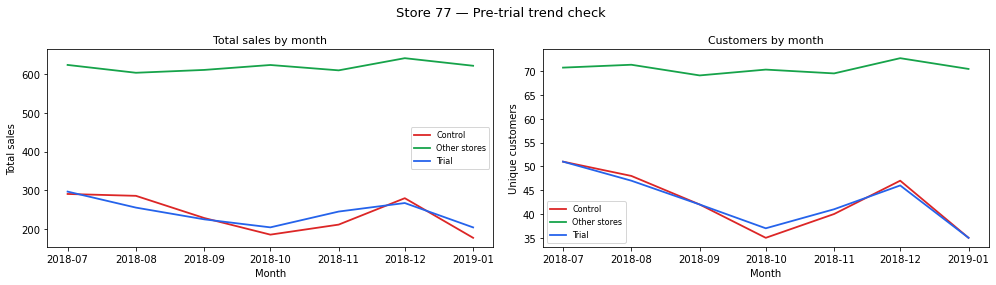

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Store 77 — Pre-trial trend check', fontsize=13)

plot_pre_trial(measure_over_time, trial_store_77, control_store_77,
               'totSales', 'Total sales', 'Total sales by month', axes[0])
plot_pre_trial(measure_over_time, trial_store_77, control_store_77,
               'nCustomers', 'Unique customers', 'Customers by month', axes[1])

plt.tight_layout()
plt.show()

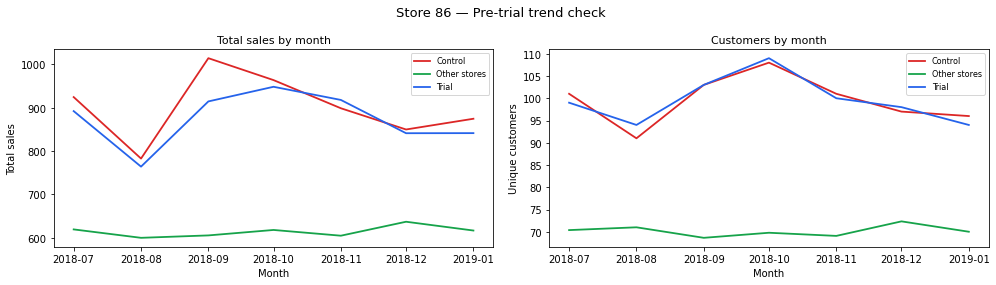

In [75]:
trial_store_77 = 86
control_store_77 = 155
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Store 86 — Pre-trial trend check', fontsize=13)

plot_pre_trial(measure_over_time, trial_store_77, control_store_77,
               'totSales', 'Total sales', 'Total sales by month', axes[0])
plot_pre_trial(measure_over_time, trial_store_77, control_store_77,
               'nCustomers', 'Unique customers', 'Customers by month', axes[1])

plt.tight_layout()
plt.show()

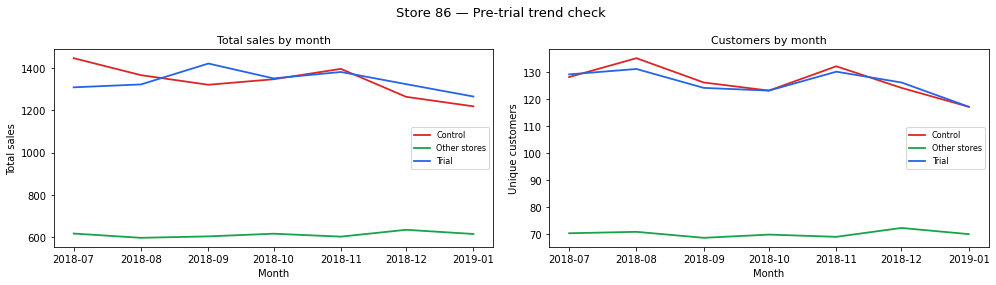

In [76]:
trial_store_77 = 88
control_store_77 = 237
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Store 86 — Pre-trial trend check', fontsize=13)

plot_pre_trial(measure_over_time, trial_store_77, control_store_77,
               'totSales', 'Total sales', 'Total sales by month', axes[0])
plot_pre_trial(measure_over_time, trial_store_77, control_store_77,
               'nCustomers', 'Unique customers', 'Customers by month', axes[1])

plt.tight_layout()
plt.show()

In [94]:
measure_over_time["YEARMONTH"].unique()

array([201807, 201808, 201809, 201810, 201811, 201812, 201901, 201902,
       201903, 201904, 201905, 201906], dtype=int64)

after validating our control stores from those vusials we go to the trial period that starts from February 2019 to April 2019 where We  want to see if there has been an uplift in overall chip sales and n_customers.

---
## 4. Scaling + t-test function

### Why scaling?
Even a well-matched control might be 10% larger than the trial store. We remove this gap by multiplying every control value by:
```
scalingFactor = sum(trial pre-trial metric) / sum(control pre-trial metric)
```
After scaling the pre-trial totals are identical, so any gap that opens *during* the trial reflects a real treatment effect.

### Why a t-test?
We measure the **% difference** between scaled-control and trial each month. In the pre-trial period this % difference is just noise — compute its standard deviation. During the trial, if the % difference is many standard deviations above that noise floor, it can't be explained by chance.

```
t = (% difference during trial − 0) / std_dev_pre_trial
```

Compare to `t_critical = t.ppf(0.95, df=7)` (8 pre-trial months − 1 = 7 degrees of freedom). If `t > t_critical` → **statistically significant uplift**.

In [86]:
def assess_trial(measure_over_time, pre_trial, trial_store, control_store,
                 metric_col, ylabel, title, ax):
    """
    Scale the control store, run the t-test, plot the confidence-interval chart.
    Returns a dict with t-values and which months were significant.
    """
    # --- Scale control to match trial pre-trial totals ---
    trial_total   = pre_trial[pre_trial['STORE_NBR'] == trial_store][metric_col].sum()
    control_total = pre_trial[pre_trial['STORE_NBR'] == control_store][metric_col].sum()
    sf = trial_total / control_total  # scaling factor

    ctrl = (
        measure_over_time[measure_over_time['STORE_NBR'] == control_store]
        [['YEARMONTH', metric_col]].copy()
    )
    ctrl['scaledControl'] = ctrl[metric_col] * sf

    trial = (
        measure_over_time[measure_over_time['STORE_NBR'] == trial_store]
        [['YEARMONTH', metric_col]].copy()
    )

    merged = trial.merge(ctrl[['YEARMONTH', 'scaledControl']], on='YEARMONTH')
    merged['pctDiff'] = (
        (merged['scaledControl'] - merged[metric_col]).abs() /
        merged['scaledControl']
    )

    # --- Baseline noise from pre-trial period ---
    pre_mask   = merged['YEARMONTH'] < 201902
    trial_mask = (merged['YEARMONTH'] >= 201902) & (merged['YEARMONTH'] < 201905)
    std_dev    = merged.loc[pre_mask, 'pctDiff'].std()
    t_critical = stats.t.ppf(0.95, df=7)

    merged['tValue'] = merged['pctDiff'] / std_dev
    sig_months = merged.loc[trial_mask & (merged['tValue'] > t_critical), 'YEARMONTH'].tolist()

    # --- Plot ---
    df = to_timestamp(measure_over_time).copy()
    ctrl_ts = to_timestamp(ctrl)

    trial_df = df[df['STORE_NBR'] == trial_store].sort_values('TransactionMonth')
    ctrl_avg = ctrl_ts.sort_values('TransactionMonth').set_index('TransactionMonth')['scaledControl']

    # Shade the trial window
    ax.axvspan(pd.Timestamp('2019-02-01'), pd.Timestamp('2019-04-30'),
               alpha=0.10, color='gray', label='Trial period')

    ax.plot(trial_df['TransactionMonth'], trial_df[metric_col],
            color=COLORS['Trial'], linewidth=1.8, label='Trial')
    ax.plot(ctrl_avg.index, ctrl_avg.values,
            color=COLORS['Control'], linewidth=1.8, label='Control (scaled)')
    ax.plot(ctrl_avg.index, ctrl_avg.values * (1 + std_dev * 2),
            color=COLORS['Control'], linewidth=1, linestyle='--', label='95th % CI')
    ax.plot(ctrl_avg.index, ctrl_avg.values * (1 - std_dev * 2),
            color=COLORS['Control'], linewidth=1, linestyle=':', label='5th % CI')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)

    return {
        't_critical':        t_critical,
        'std_dev':           std_dev,
        'significant_months': sig_months,
        'trial_tvalues':     merged.loc[trial_mask, ['YEARMONTH', 'tValue']].round(3)
    }

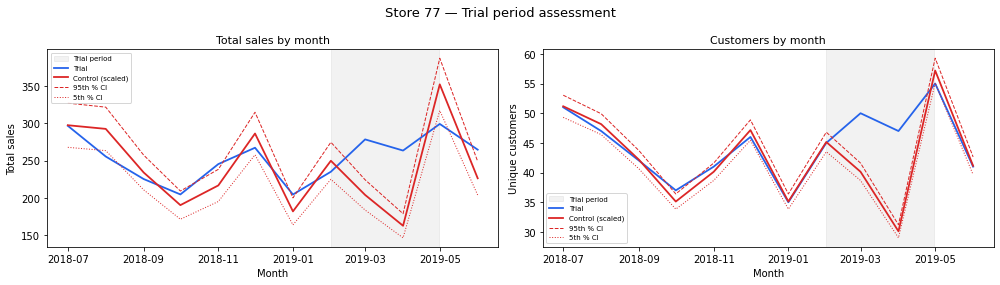


t-critical (95th pct, df=7): 1.8946

Sales t-values during trial:
 YEARMONTH  tValue
    201902   1.184
    201903   7.339
    201904  12.476

Customer t-values during trial:
 YEARMONTH  tValue
    201902   0.183
    201903  13.476
    201904  30.779

Significant months (sales):     [201903, 201904]
Significant months (customers): [201903, 201904]


In [87]:
trial_store_77 = 77
control_store_77 = 233

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Store 77 — Trial period assessment', fontsize=13)

r77_sales = assess_trial(
    measure_over_time, pretrial, trial_store_77, control_store_77,
    'totSales', 'Total sales', 'Total sales by month', axes[0]
)
r77_custs = assess_trial(
    measure_over_time, pretrial, trial_store_77, control_store_77,
    'nCustomers', 'Unique customers', 'Customers by month', axes[1]
)

plt.tight_layout()
plt.show()

print(f"\nt-critical (95th pct, df=7): {r77_sales['t_critical']:.4f}")
print('\nSales t-values during trial:')
print(r77_sales['trial_tvalues'].to_string(index=False))
print('\nCustomer t-values during trial:')
print(r77_custs['trial_tvalues'].to_string(index=False))
print(f"\nSignificant months (sales):     {r77_sales['significant_months']}")
print(f"Significant months (customers): {r77_custs['significant_months']}")

**Interpretation — Store 77:** The trial store's performance lies **outside** the 5–95% confidence interval of the control in at least 2 of 3 trial months for both sales and customers → **significant positive uplift**.

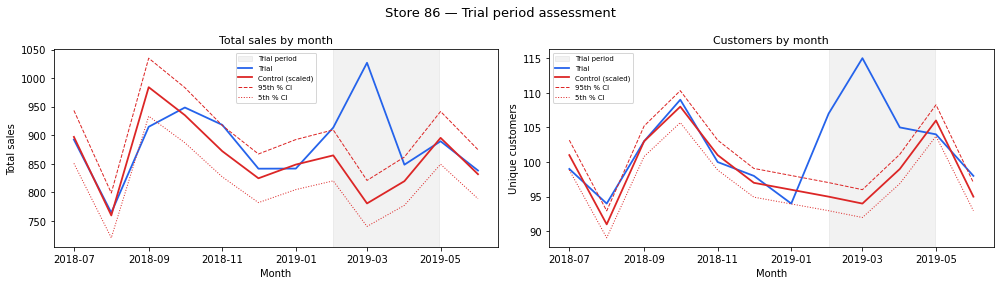


t-critical (95th pct, df=7): 1.8946

Sales t-values during trial:
 YEARMONTH  tValue
    201902   2.180
    201903  12.227
    201904   1.365

Customer t-values during trial:
 YEARMONTH  tValue
    201902  11.819
    201903  20.903
    201904   5.671

Significant months (sales):     [201902, 201903]
Significant months (customers): [201902, 201903, 201904]


In [90]:
trial_store_86 = 86
control_store_86 = 155
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Store 86 — Trial period assessment', fontsize=13)

r86_sales = assess_trial(
    measure_over_time, pretrial, trial_store_86, control_store_86,
    'totSales', 'Total sales', 'Total sales by month', axes[0]
)
r86_custs = assess_trial(
    measure_over_time, pretrial, trial_store_86, control_store_86,
    'nCustomers', 'Unique customers', 'Customers by month', axes[1]
)

plt.tight_layout()
plt.show()

print(f"\nt-critical (95th pct, df=7): {r86_sales['t_critical']:.4f}")
print('\nSales t-values during trial:')
print(r86_sales['trial_tvalues'].to_string(index=False))
print('\nCustomer t-values during trial:')
print(r86_custs['trial_tvalues'].to_string(index=False))
print(f"\nSignificant months (sales):     {r86_sales['significant_months']}")
print(f"Significant months (customers): {r86_custs['significant_months']}")

**Interpretation — Store 86:** Customers increased significantly in all 3 trial months, but **sales were not significantly higher**. The likely explanation is that a price promotion during the trial brought in more customers but at lower margins. Worth checking with the Category Manager whether any deals were run in-store.

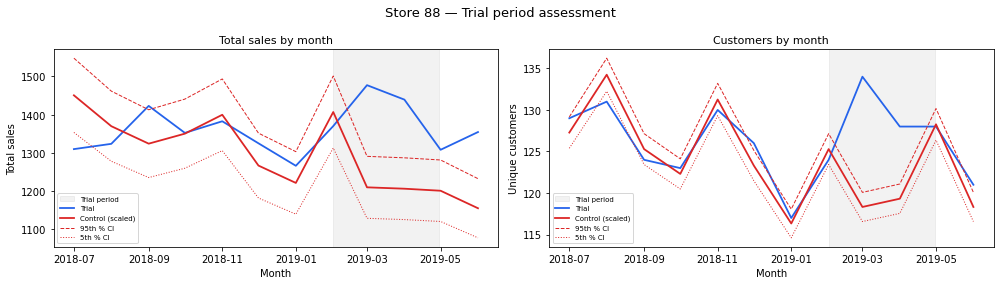


t-critical (95th pct, df=7): 1.8946

Sales t-values during trial:
 YEARMONTH  tValue
    201902   0.781
    201903   6.596
    201904   5.769

Customer t-values during trial:
 YEARMONTH  tValue
    201902   1.387
    201903  17.874
    201904   9.814

Significant months (sales):     [201903, 201904]
Significant months (customers): [201903, 201904]


In [91]:
trial_store_88 = 88
control_store_88 = 237

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Store 88 — Trial period assessment', fontsize=13)

r88_sales = assess_trial(
    measure_over_time, pretrial, trial_store_88, control_store_88,
    'totSales', 'Total sales', 'Total sales by month', axes[0]
)
r88_custs = assess_trial(
    measure_over_time, pretrial, trial_store_88, control_store_88,
    'nCustomers', 'Unique customers', 'Customers by month', axes[1]
)

plt.tight_layout()
plt.show()

print(f"\nt-critical (95th pct, df=7): {r88_sales['t_critical']:.4f}")
print('\nSales t-values during trial:')
print(r88_sales['trial_tvalues'].to_string(index=False))
print('\nCustomer t-values during trial:')
print(r88_custs['trial_tvalues'].to_string(index=False))
print(f"\nSignificant months (sales):     {r88_sales['significant_months']}")
print(f"Significant months (customers): {r88_custs['significant_months']}")

**Interpretation — Store 88:** Like store 77, both sales and customers are significantly higher in at least 2 of 3 trial months → **significant positive uplift**.

##  Conclusion
**Overall:** The trial shows a significant positive effect on chip sales across the three stores. Store 86 is an anomaly — higher footfall without a proportional sales lift suggests a confounding factor such as promotional pricing during the trial period. This should be investigated with the Category Manager before rolling out the new layout more broadly.